# Breast Cancer Classification Using Machine Learning

## Objective

The objective of this project is to build a machine learning model that can classify breast cancer cases as benign or malignant.

The project demonstrates data preprocessing, feature scaling, model training, prediction, and evaluation using accuracy, classification report, confusion matrix, ROC curve, and AUC.

## Dataset

The Breast Cancer Wisconsin (Original) dataset from the UCI Machine Learning Repository was used for this project.

## Machine Learning Algorithm

A Support Vector Machine (SVM) classifier with a linear kernel was used for binary classification.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc
)

In [2]:
column_names = [
    'Sample_code_number',
    'Clump_Thickness',
    'Uniformity_Cell_Size',
    'Uniformity_Cell_Shape',
    'Marginal_Adhesion',
    'Single_Epithelial_Cell_Size',
    'Bare_Nuclei',
    'Bland_Chromatin',
    'Normal_Nucleoli',
    'Mitoses',
    'Class'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

df = pd.read_csv(url, names=column_names)

display(df.head())
print("Dataset shape:", df.shape)

,Sample_code_number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Dataset shape: (699, 11)


In [6]:
column_names = [
    'Sample_code_number',
    'Clump_Thickness',
    'Uniformity_Cell_Size',
    'Uniformity_Cell_Shape',
    'Marginal_Adhesion',
    'Single_Epithelial_Cell_Size',
    'Bare_Nuclei',
    'Bland_Chromatin',
    'Normal_Nucleoli',
    'Mitoses',
    'Class'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

df = pd.read_csv(url, names=column_names)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (699, 11)


,Sample_code_number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

print("\nClass distribution:")
print(df['Class'].value_counts())

Missing values:
Sample_code_number             0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_code_number           699 non-null    int64 
 1   Clump_Thickness              699 non-null    int64 
 2   Uniformity_Cell_Size         699 non-null    int64 
 3   Uniformity_Cell_Shape        699 non-null    int64 
 4   Marginal_Adhesion            699 non-null    int64 
 5   Single_Epithelial_Cell_Size  699 non-null    int64 
 6   Bare_Nuclei         

In [8]:
df = df.replace('?', np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
Sample_code_number              0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [9]:
df = df.dropna()

print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (683, 11)


In [10]:
X = df.iloc[:, 1:10]
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (683, 9)
Target shape: (683,)


In [11]:
y = np.where(y == 4, 1, 0)

print("Target classes:")
print(np.unique(y, return_counts=True))

Target classes:
(array([0, 1]), array([444, 239]))


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 478
Testing samples: 205


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [15]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 96.1 %


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Benign', 'Malignant']
))

              precision    recall  f1-score   support

      Benign       0.98      0.96      0.97       133
   Malignant       0.93      0.96      0.95        72

    accuracy                           0.96       205
   macro avg       0.95      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



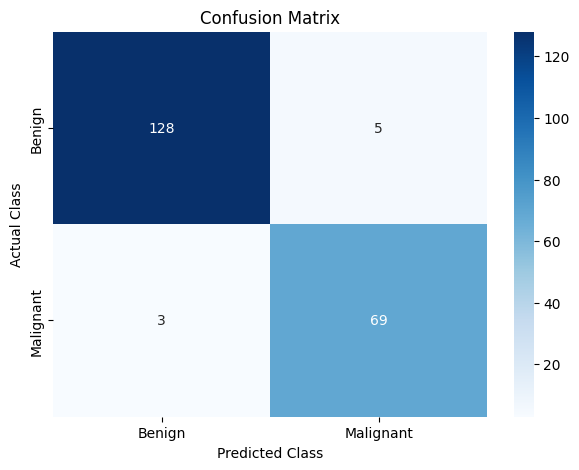

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

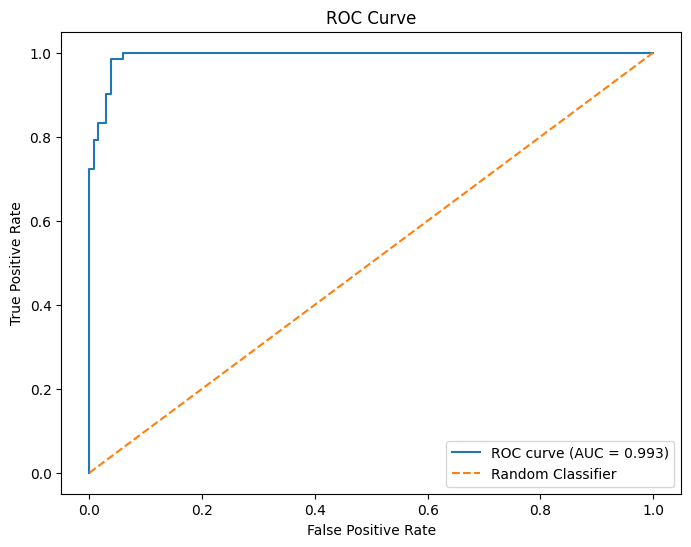

AUC: 0.993


In [18]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("AUC:", round(roc_auc, 3))

# Key Findings

- The Breast Cancer Wisconsin dataset was cleaned by handling missing values.
- The data was divided into training and testing sets using a 70:30 split.
- Feature scaling was performed before training the SVM model.
- The SVM classifier achieved an accuracy of 96.1% on the test dataset.
- The classification report showed strong precision, recall, and F1-score for both benign and malignant classes.
- The confusion matrix showed that most cases were classified correctly.
- The ROC curve produced an AUC score of 0.993, indicating strong classification performance on the test dataset.

# Conclusion

This project demonstrates a complete supervised machine learning workflow for breast cancer classification. The dataset was preprocessed, divided into training and testing sets, standardized, and used to train a Support Vector Machine classifier. The model was evaluated using accuracy, classification metrics, a confusion matrix, and an ROC curve with AUC. The results show that the trained SVM model performed well in distinguishing between benign and malignant cases in the test dataset.

In [20]:
df.to_csv("breast_cancer_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
